<a href="https://colab.research.google.com/github/Revanth-reddy080/PyTorch-DeepLearning/blob/main/exercises/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Check for GPU
!nvidia-smi

Tue Jul  7 00:45:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

## 1. What are 3 areas in industry where computer vision is currently being used?

In [5]:
# 1. Auto pilot for Cars
# 2. object detection in security
# 3. Health care vison

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

overfitting - fitting the model perfectlly to train data.

where train loss is  near 0 and test loss is higher ,so it is not generalized.
it will predict exact answers for test dat. But not for new data ,i.e it is lack of generalisation.

Also called high variance.



## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

we solve this problem by ,
1. L2 regularization - add regularization term to loss function and then asusual try to minimize it

2. Data set augementation -  Create data from exsiting data ,as by rotating,blurring few pixels .works well for object detection and image classification

3. parameter sharing and tying - its typically what we toin CNN,like for all inputs we use same filter right(we can increase number of filters though)

4. Add Noise to inputs and outputs
5. Early stopping
6. Ensemble Methods
7. Dropout

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [9]:
import torchvision
from torchvision import datasets
from torchvision import transforms

In [11]:
train_data = datasets.MNIST(root="data",
                            train=True,
                            download=True,
                            transform=transforms.ToTensor())

test_data = datasets.MNIST(root="data",
                           download=True,
                           train=False,
                           transform=transforms.ToTensor())

100%|██████████| 9.91M/9.91M [00:00<00:00, 12.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 335kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.17MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.79MB/s]


In [12]:
train_data,test_data

(Dataset MNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset MNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

In [15]:
train_data[2][1]

4

In [17]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [18]:
img ,label = train_data[0]
img.shape,label

(torch.Size([1, 28, 28]), 5)

## 6. Visualize at least 5 different samples of the MNIST training dataset.

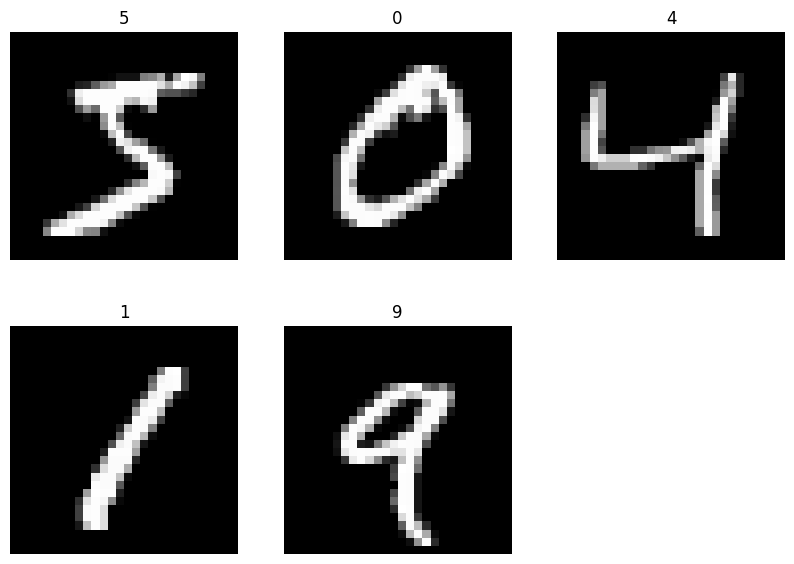

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))

for i in range(5):
  img , label = train_data[i]
  plt.subplot(2,3,i+1)
  plt.imshow(img.permute(1,2,0),cmap="gray")
  plt.title(label)
  plt.axis(False)

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [29]:
from torch.utils.data.dataloader import DataLoader

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=32,
                              shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size = 32,
                             shuffle=False)

for sample in next(iter(train_dataloader)):
  print(sample.shape)

torch.Size([32, 1, 28, 28])
torch.Size([32])


## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [35]:
import torch
from torch import nn
class MNISTModelV2(nn.Module):
  def __init__(self,input_shape : int,
                    hidden_units:int,
                    output_shape:int):
    super().__init__()

    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.linear_layer = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*4*4,
                              out_features=10)
    )

  def forward(self,x):
    return self.linear_layer(self.conv_block_2(self.conv_block_1(x)))

In [37]:
model = MNISTModelV2(input_shape=1,
                     hidden_units=16,
                     output_shape=10)
model.to(device)
model

MNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [41]:
x = torch.rand(size=(1,28,28)).unsqueeze(dim=1).to(device)
model(x)

tensor([[ 0.0151,  0.0486,  0.0687,  0.0204, -0.0569,  0.0603,  0.0542, -0.0116,
          0.0450,  0.0281]], device='cuda:0', grad_fn=<AddmmBackward0>)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [ ]:
# train on cpu
model_0= MNISTModelV2(input_shape=1,
                     hidden_units=16,
                     output_shape=10)
model_0.to("cpu")


In [44]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)

In [46]:
from sklearn.metrics import accuracy_score

In [52]:
from tqdm.auto import tqdm
from timeit import default_timer as timer

start_time = timer()

for epoch in tqdm(range(5)):
  model_0.train()

  train_loss = 0;
  acc = 0;

  for batch , (X,y) in enumerate(train_dataloader):

    X,y = X.to("cpu"),y.to("cpu")

    y_pred = model_0(X)

    loss = loss_fn(y_pred,y)
    train_loss += loss
    acc +=accuracy_score(y_true=y,y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /=len(train_dataloader)
  acc/=len(train_dataloader)

  test_loss = 0
  test_acc =0

  model_0.eval()

  with torch.inference_mode():

    for batch ,(X,y) in enumerate(test_dataloader):

      X,y =X.to("cpu"),y.to("cpu")

      test_pred = model_0(X)

      test_loss += loss_fn(test_pred,y)
      test_acc +=accuracy_score(y_true=y ,y_pred=test_pred.argmax(dim=1))

    test_loss /=len(test_dataloader)
    test_acc/=len(test_dataloader)


  print(f"Epoch :{epoch} | Train Loss:{train_loss:.3f} | Train acc:{acc:.2f} | Test Loss:{test_loss:.3f} | Test acc:{test_acc:.2f}")

end_time =timer()

print(f"Time taken on cpu :{end_time-start_time}")


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch :0 | Train Loss:0.041 | Train acc:0.99 | Test Loss:0.038 | Test acc:0.99
Epoch :1 | Train Loss:0.035 | Train acc:0.99 | Test Loss:0.043 | Test acc:0.99
Epoch :2 | Train Loss:0.033 | Train acc:0.99 | Test Loss:0.040 | Test acc:0.99
Epoch :3 | Train Loss:0.030 | Train acc:0.99 | Test Loss:0.035 | Test acc:0.99
Epoch :4 | Train Loss:0.027 | Train acc:0.99 | Test Loss:0.035 | Test acc:0.99
Time taken on cpu :237.88838793099967


In [53]:
model_1= MNISTModelV2(input_shape=1,
                     hidden_units=16,
                     output_shape=10)
model_1.to(device)


MNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (linear_layer): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=256, out_features=10, bias=True)
  )
)

In [54]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)

In [56]:

# train on gpu

start_time = timer()

for epoch in tqdm(range(5)):
  model_1.train()

  train_loss = 0;
  acc = 0;

  for batch , (X,y) in enumerate(train_dataloader):

    X,y = X.to(device),y.to(device)

    y_pred = model_1(X)

    loss = loss_fn(y_pred,y)
    train_loss += loss

    acc +=accuracy_score(y_true=y.cpu(),y_pred=y_pred.argmax(dim=1).cpu())

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

  train_loss /=len(train_dataloader)
  acc/=len(train_dataloader)

  test_loss = 0
  test_acc =0

  model_1.eval()

  with torch.inference_mode():

    for batch ,(X,y) in enumerate(test_dataloader):

      X,y =X.to(device),y.to(device)

      test_pred = model_1(X)

      test_loss += loss_fn(test_pred,y)
      # Move y and test_pred to CPU before passing to accuracy_score
      test_acc +=accuracy_score(y_true=y.cpu() ,y_pred=test_pred.argmax(dim=1).cpu())

    test_loss /=len(test_dataloader)
    test_acc/=len(test_dataloader)


  print(f"Epoch :{epoch} | Train Loss:{train_loss:.3f} | Train acc:{acc:.2f} | Test Loss:{test_loss:.3f} | Test acc:{test_acc:.2f}")

end_time =timer()

print(f"Time taken on gpu :{end_time-start_time}")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch :0 | Train Loss:0.240 | Train acc:0.92 | Test Loss:0.070 | Test acc:0.98
Epoch :1 | Train Loss:0.075 | Train acc:0.98 | Test Loss:0.051 | Test acc:0.98
Epoch :2 | Train Loss:0.056 | Train acc:0.98 | Test Loss:0.057 | Test acc:0.98
Epoch :3 | Train Loss:0.046 | Train acc:0.98 | Test Loss:0.049 | Test acc:0.98
Epoch :4 | Train Loss:0.041 | Train acc:0.99 | Test Loss:0.039 | Test acc:0.99
Time taken on gpu :78.86683458600055


## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [63]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
            # Prepare sample
            sample = torch.unsqueeze(sample, dim=0).to(device) # Add an extra dimension and send sample to device

            # Forward pass (model outputs raw logit)
            pred_logit = model(sample)

            # Get prediction probability (logit -> prediction probability)
            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 1, so can perform on dim=0)

            # Get pred_prob off GPU for further calculations
            pred_probs.append(pred_prob.cpu())

    # Stack the pred_probs to turn list into a tensor
    return torch.stack(pred_probs)

In [75]:
import random
#random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first test sample shape and label
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 9 


In [76]:
# Make predictions on test samples with model 2
pred_probs= make_predictions(model=model_1,
                             data=test_samples)

# View first two prediction probabilities list
pred_labels = pred_probs.argmax(dim=1)

pred_labels,test_labels

(tensor([9, 6, 2, 9, 3, 2, 2, 3, 6]), [9, 6, 2, 9, 3, 2, 2, 3, 6])

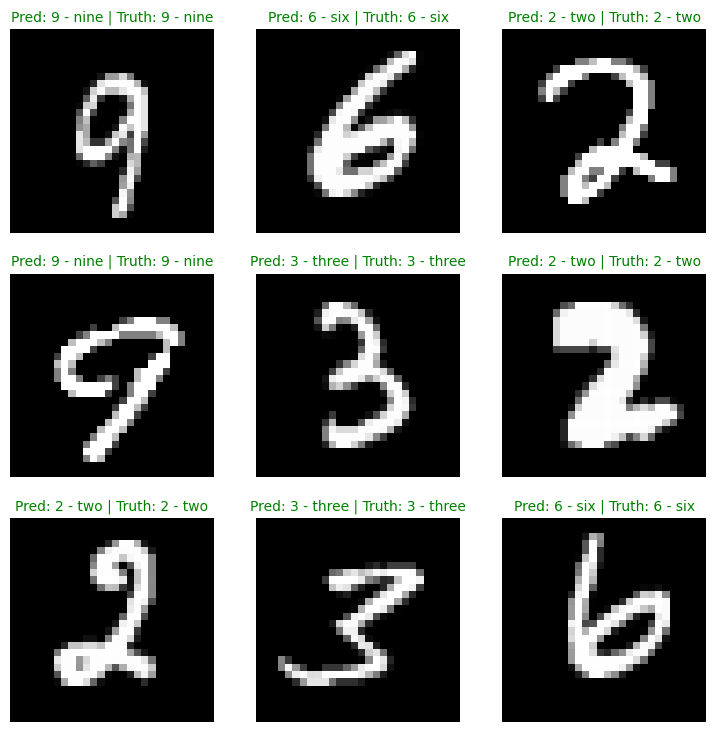

In [77]:
# Plot predictions
plt.figure(figsize=(9, 9))
nrows = 3
ncols = 3
for i, sample in enumerate(test_samples):
  # Create a subplot
  plt.subplot(nrows, ncols, i+1)

  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")

  # Find the prediction label (in text form, e.g. "Sandal")
  pred_label = class_names[pred_labels[i]]

  # Get the truth label (in text form, e.g. "T-shirt")
  truth_label = class_names[test_labels[i]]

  # Create the title text of the plot
  title_text = f"Pred: {pred_label} | Truth: {truth_label}"

  # Check for equality and change title colour accordingly
  if pred_label == truth_label:
      plt.title(title_text, fontsize=10, c="g") # green text if correct
  else:
      plt.title(title_text, fontsize=10, c="r") # red text if wrong
  plt.axis(False);

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [78]:
preds=[]
model_1.eval()

with torch.inference_mode():

  for batch ,(X,y) in enumerate(test_dataloader):

    X,y = X.to(device),y.to(device)

    y_logit = model_1(X)

    y_preds = y_logit.argmax(dim=1)

    preds.append(y_preds.cpu())

y_pred_tensor = torch.cat(preds)

In [ ]:
!pip install torchmetrics

In [85]:
from torchmetrics import ConfusionMatrix

confmat = ConfusionMatrix(num_classes=10,task="multiclass")
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

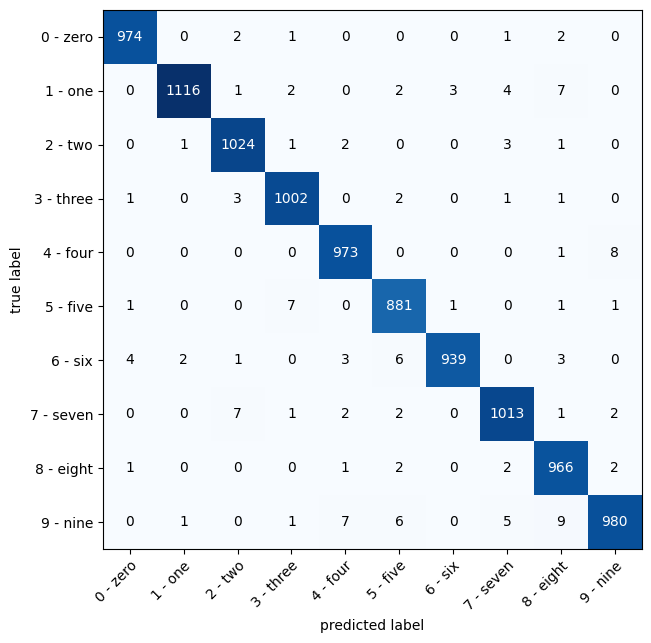

In [87]:
from mlxtend.plotting import plot_confusion_matrix

fig ,ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=train_data.classes,
    figsize=(10,7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [94]:
random_tensor = torch.rand(size=(1,3,64,64))
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=16,
                       kernel_size=3,
                       stride=2,
                       padding=0)
tensor_through_conv_layer = conv_layer(random_tensor)
random_tensor.shape,tensor_through_conv_layer.shape

(torch.Size([1, 3, 64, 64]), torch.Size([1, 16, 31, 31]))

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?